# Graph utilities

In [2]:
import numpy as np
import scipy.sparse as sp

# pip install networkx numpy
import networkx as nx
from typing import List, Tuple, Dict

from itertools import product

def _edges_from_str_pairs(pairs: List[str], one_based=True) -> List[Tuple[int,int]]:
    """
    Convert compact edge notation like ["12","13","58"] to list of (u,v) tuples.
    If one_based=True, vertices are 1..8; otherwise 0..7.
    """
    edges = []
    for s in pairs:
        if len(s) != 2 or not s.isdigit():
            raise ValueError(f"Bad edge code: {s!r}")
        u, v = int(s[0]), int(s[1])
        if not one_based:
            u -= 1; v -= 1
        if u == v:
            raise ValueError(f"Loop edge not allowed: {s}")
        edges.append((u, v) if u < v else (v, u))
    return sorted(set(edges))

def cubic_graphs_n8_from_lists(
    zero_based: bool = False,
    want_matrices: bool = True,
    check_connected: bool = False,
) -> Dict[str, Dict[str, object]]:
    """
    Build the 6 non-isomorphic 3-regular graphs on 8 vertices using provided edge-lists.

    Parameters
    ----------
    zero_based : bool
        If True, relabel vertices to 0..7 in outputs; otherwise keep 1..8.
    want_matrices : bool
        If True, include 8x8 numpy adjacency matrices in the result.
    check_connected : bool
        If True, assert which graphs are connected.

    Returns
    -------
    dict
        keys: "Graph 1".."Graph 6"
        values: dict with fields:
            - "edges": list[(u,v)]
            - "G": networkx.Graph
            - "A": np.ndarray (8x8) if want_matrices=True
            - "notes": str (for known named graphs)
    """
    # Your 6 edge-lists (one-based labels)
    raw = {
        "Graph 1": ["12","13","14","23","24","34","56","57","58","67","68","78"],
        "Graph 2": ["12","13","14","24","34","26","37","56","57","58","68","78"],
        "Graph 3": ["12","13","23","14","47","25","58","36","45","67","68","78"],
        "Graph 4": ["12","13","23","14","25","36","47","48","57","58","67","68"],
        "Graph 5": ["12","13","24","34","15","26","37","48","56","57","68","78"],
        "Graph 6": ["12","23","34","45","56","67","78","18","15","26","37","48"],
    }

    # Known names for three of them
    notes = {
        "Graph 1": "K4 ⊔ K4 (disconnected)",
        "Graph 5": "Cube graph Q3 (a.k.a. 4-prism C4 □ K2)",
        "Graph 6": "Möbius/Wagner graph M8 (C8 + opposite chords)",
    }

    result = {}
    for name, pair_list in raw.items():
        edges = _edges_from_str_pairs(pair_list, one_based=True)

        # Build graph with 1..8 nodes
        G = nx.Graph()
        G.add_nodes_from(range(1, 9))
        G.add_edges_from(edges)

        # Sanity: 3-regular?
        degs = [d for _, d in G.degree()]
        assert all(d == 3 for d in degs), f"{name} is not 3-regular: degrees={degs}"

        if check_connected:
            # Expect all except Graph 1 to be connected
            if name == "Graph 1":
                assert not nx.is_connected(G), f"{name} should be disconnected"
            else:
                assert nx.is_connected(G), f"{name} should be connected"

        # Optional relabel 0..7
        if zero_based:
            mapping = {i: i-1 for i in range(1, 9)}
            G = nx.relabel_nodes(G, mapping)
            edges_ob = sorted((min(u, v), max(u, v)) for (u, v) in G.edges())
            nodes = list(range(8))
        else:
            edges_ob = edges
            nodes = list(range(1, 9))

        entry = {
            "edges": edges_ob,
            "G": G,
            "notes": notes.get(name, ""),
        }

        if want_matrices:
            A = nx.to_numpy_array(G, nodelist=nodes, dtype=int)
            entry["A"] = A

        result[name] = entry

    return result

def band_matrix_n_qubits(n, bandwidth, periodic=False, sparse=False):
    """
    Hermitian band matrix on n qubits (size d=2**n).
    - Diagonal is always zero.
    - Off-diagonals within |i-j|<=bandwidth are 1.
    - If periodic=True, wrap-around distance is used.
    """
    d = 1 << n
    w = max(0, min(int(bandwidth), d-1))
    if w == 0:
        return sp.csr_matrix((d, d)) if (sparse and sp) else np.zeros((d, d), float)

    if sparse and sp is not None:
        diags = []
        offs  = []
        # non-periodic band: offsets ±1..±w
        for k in range(1, w+1):
            diags += [np.ones(d-k), np.ones(d-k)]
            offs  += [ k, -k]
        # periodic wrap: offsets ±(d-k)
        if periodic:
            for k in range(1, w+1):
                diags += [np.ones(k), np.ones(k)]
                offs  += [ d-k, k-d]
        A = sp.diags(diags, offs, shape=(d, d), format="csr")
        A.setdiag(0)  # ensure zero diagonal
        return A
    else:
        if periodic:
            # circulant band: min(|i-j|, d-|i-j|) <= w
            idx = np.arange(d)
            A = np.zeros((d, d), float)
            for k in range(1, w+1):
                A[idx, (idx+k) % d] = 1
                A[idx, (idx-k) % d] = 1
        else:
            A = np.zeros((d, d), float)
            for k in range(1, w+1):
                A[np.arange(d-k), np.arange(k, d)] = 1
                A[np.arange(k, d), np.arange(d-k)] = 1
        np.fill_diagonal(A, 0)
        return A

# Dense (NumPy) and Sparse (SciPy) adjacency for the n-dimensional hypercube Q_n
import numpy as np

def hypercube_adjacency_dense(n: int, dtype=int) -> np.ndarray:
    """
    Return the 2^n x 2^n dense adjacency matrix of the n-dimensional hypercube Q_n.
    Vertex i (0..2^n-1) is connected to i^ (1<<b) for each bit b in [0, n).
    """
    if n < 0:
        raise ValueError("n must be >= 0")
    N = 1 << n  # number of vertices
    A = np.zeros((N, N), dtype=dtype)
    for i in range(N):
        for b in range(n):
            j = i ^ (1 << b)  # flip bit b
            A[i, j] = 1
            A[j, i] = 1
    return A


# Optional: faster & memory-friendly sparse version
from scipy.sparse import coo_matrix, csr_matrix

def hypercube_adjacency_sparse(n: int) -> csr_matrix:
    """
    Return the 2^n x 2^n CSR sparse adjacency matrix of Q_n.
    """
    if n < 0:
        raise ValueError("n must be >= 0")
    N = 1 << n
    rows, cols = [], []
    for i in range(N):
        for b in range(n):
            j = i ^ (1 << b)
            rows.append(i); cols.append(j)
            rows.append(j); cols.append(i)  # add symmetric entry
    data = np.ones(len(rows), dtype=int)
    return coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()

def random_graph(
    n=None,
    p=None,
    d=None,
    degree_sequence=None,
    *,
    seed=None,
    simple=True,
    allow_self_loops=False,
    return_matrix=True,
    max_tries=10_000,
):
    """
    One-stop random graph generator.

    Modes (auto-detected by provided args):
      • G(n,p):            provide n and p
      • d-regular:         provide n and d
      • fixed degree seq:  provide degree_sequence (list of ints)

    Args:
      n: number of nodes (0..n-1). Required for G(n,p) and d-regular.
      p: edge probability (G(n,p)).
      d: degree per node (d-regular).
      degree_sequence: exact degrees per node (len = n if n given, else inferred).
      seed: RNG seed (int or None).
      simple: enforce simple graph (no multi-edges; and no self-loops unless allow_self_loops=True).
      allow_self_loops: allow u==v edges (ignored for G(n,p) which already avoids them).
      return_matrix: return adjacency matrix instead of edge list.
      max_tries: max rejection attempts for simple configuration-model sampling.

    Returns:
      Edge list [(u,v), ...] with u<v if simple, else arbitrary pairs; or adjacency matrix if return_matrix=True.
    """
    import random
    rng = random.Random(seed)

    # ---------------- helpers (scoped) ----------------
    def to_adj_matrix(edges, nn):
        A = [[0]*nn for _ in range(nn)]
        for u, v in edges:
            A[u][v] += 1
            A[v][u] += 1
        return np.array(A)

    def check_simple(edges, nn, allow_loops):
        if not allow_loops:
            for u, v in edges:
                if u == v:
                    return False
        seen = set()
        for u, v in edges:
            a, b = (u, v) if u <= v else (v, u)
            if (a, b) in seen:
                return False
            seen.add((a, b))
        return True

    def erdos_gallai(deg):
        d_sorted = sorted(deg, reverse=True)
        if any(x < 0 for x in d_sorted): return False
        if sum(d_sorted) % 2: return False
        pref = [0]
        for x in d_sorted: pref.append(pref[-1]+x)
        m = len(d_sorted)
        for k in range(1, m+1):
            left = pref[k]
            right = k*(k-1) + sum(min(x, k) for x in d_sorted[k:])
            if left > right: return False
        return True

    def config_model(deg, nn):
        if any(dv < 0 for dv in deg):
            raise ValueError("Degrees must be nonnegative.")
        if sum(deg) % 2 != 0:
            raise ValueError("Sum of degrees must be even.")
        stubs_template = []
        for v, dv in enumerate(deg):
            stubs_template.extend([v]*dv)
        for _ in range(max_tries):
            stubs = stubs_template[:]
            rng.shuffle(stubs)
            edges = [(stubs[i], stubs[i+1]) for i in range(0, len(stubs), 2)]
            if simple:
                if not check_simple(edges, nn, allow_self_loops):
                    continue
                # normalize pairs to u<v if simple
                edges = [(u, v) if u < v else (v, u) for u, v in edges]
                # deduplicate (should be none if truly simple)
                edges = list(dict.fromkeys(edges))
            return edges
        raise RuntimeError("Failed to sample a simple graph with the given degree data (increase max_tries or relax constraints).")

    # ---------------- mode selection ----------------
    mode = None
    if degree_sequence is not None:
        deg = list(degree_sequence)
        nn = len(deg) if n is None else n
        if n is not None and len(deg) != n:
            raise ValueError("len(degree_sequence) must equal n when n is provided.")
        if simple and not erdos_gallai(deg):
            raise ValueError("Degree sequence is not graphical (Erdős–Gallai failed) with simple=True.")
        mode = "degree_sequence"
    elif d is not None:
        if n is None:
            raise ValueError("n is required for d-regular graphs.")
        if d < 0:
            raise ValueError("d must be >= 0.")
        if simple and d >= n:
            raise ValueError("For simple graphs, require d < n.")
        if (n * d) % 2 != 0:
            raise ValueError("n*d must be even.")
        deg = [d]*n
        nn = n
        mode = "d_regular"
    elif (n is not None) and (p is not None):
        if not (0.0 <= p <= 1.0):
            raise ValueError("p must be in [0,1].")
        nn = n
        mode = "gnp"
    else:
        raise ValueError("Ambiguous inputs. Provide either (n,p) OR (n,d) OR degree_sequence.")

    # ---------------- sampling ----------------
    if mode in ("degree_sequence", "d_regular"):
        edges = config_model(deg, nn)
    else:  # G(n,p)
        edges = []
        for u in range(nn):
            for v in range(u+1, nn):
                if rng.random() < p:
                    edges.append((u, v))

    return to_adj_matrix(edges, nn) if return_matrix else edges

def lattice_adjacency(shape, periodic=False, gray_permute=False, return_perm=False):
    """
    Generate the adjacency matrix of a D-dimensional lattice graph.

    Parameters
    ----------
    shape : tuple of ints
        Number of sites per dimension, e.g. (3,3,3) for a 3x3x3 lattice.
    periodic : bool, optional
        If True, use periodic boundary conditions along each dimension.
        If False, use open boundary conditions. Default is False.
    gray_permute : bool, optional
        If True, permute rows and columns so that along each dimension
        coordinate index i is mapped to its Gray code index i' = i ^ (i >> 1).
        Requires each shape[d] to be a power of 2.
    return_perm : bool, optional
        If True, also return the permutation array `perm` such that
        A_gray = A[np.ix_(perm, perm)].

    Returns
    -------
    A : np.ndarray, shape (N, N)
        Adjacency matrix, where N = prod(shape).
    perm : np.ndarray, shape (N,), optional
        The permutation used for Gray ordering (only if return_perm=True).
    """
    shape = tuple(shape)
    dims = len(shape)
    N = int(np.prod(shape))
    A = np.zeros((N, N), dtype=int)

    # Map D-dimensional coordinate -> single index in [0, N)
    def coord_to_index(coord):
        idx = 0
        stride = 1
        # row-major: last dimension changes fastest
        for d in reversed(range(dims)):
            idx += coord[d] * stride
            stride *= shape[d]
        return idx

    # Build adjacency in the standard (lexicographic) ordering
    for coord in product(*[range(s) for s in shape]):
        i = coord_to_index(coord)

        for d in range(dims):
            for delta in (-1, 1):
                neighbor = list(coord)
                neighbor[d] += delta

                # Handle boundaries
                if periodic:
                    neighbor[d] %= shape[d]
                else:
                    if not (0 <= neighbor[d] < shape[d]):
                        continue

                j = coord_to_index(tuple(neighbor))
                A[i, j] = 1
                A[j, i] = 1  # ensure symmetry

    # Optionally permute using per-dimension Gray coding
    if gray_permute:
        # require each dimension length to be a power of 2
        for s in shape:
            if s & (s - 1) != 0:
                raise ValueError(
                    f"Gray permutation requires each dimension size to be a power of 2, "
                    f"but got shape={shape}."
                )

        def gray(i):
            return i ^ (i >> 1)

        perm = np.empty(N, dtype=int)

        # For each coordinate in standard order, map to Gray-coded coordinate
        for coord in product(*[range(s) for s in shape]):
            idx = coord_to_index(coord)
            gray_coord = tuple(gray(c) for c in coord)
            idx_gray = coord_to_index(gray_coord)
            perm[idx] = idx_gray

        # Apply permutation: A' = P A P^T
        A = A[np.ix_(perm, perm)]

        if return_perm:
            return A, perm
        else:
            return A

    # No Gray permutation
    if return_perm:
        perm = np.arange(N, dtype=int)
        return A, perm
    else:
        return A

# Example usage:
shape = (4, 4)  # 2D 4x4 lattice, each dimension has 2^2 sites
A_standard = lattice_adjacency(shape, periodic=False, gray_permute=False)
A_gray, perm = lattice_adjacency(shape, periodic=False, gray_permute=True, return_perm=True)

print("Standard adjacency shape:", A_standard.shape)
print("Gray-ordered adjacency shape:", A_gray.shape)
print("Permutation:", perm)


# Example usage
if __name__ == "__main__":
    # Example usage:
    shape = (8,)  # 3x3x3 lattice
    A = lattice_adjacency(shape, periodic=False, gray_permute=True)
    print(A.shape)  # (27, 27)
    print(A)

/home/jchen9/pauli_first_quantization/.venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Standard adjacency shape: (16, 16)
Gray-ordered adjacency shape: (16, 16)
Permutation: [ 0  1  3  2  4  5  7  6 12 13 15 14  8  9 11 10]
(8, 8)
[[0 1 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 1]
 [0 1 1 0 0 0 0 0]
 [0 0 0 0 0 1 1 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 1]
 [0 0 1 0 0 0 1 0]]


# Optimization utilities

In [81]:
import numpy as np
import itertools
import cvxpy as cp
from scipy.sparse import coo_matrix
import random


###############################################################################
# TWO-PARTICLE BASIS |ij>, 0 <= i < j < q
###############################################################################

def two_particle_basis(q):
    pairs = []
    index_of = {}
    idx = 0
    for i in range(q):
        for j in range(i + 1, q):
            pairs.append((i, j))
            index_of[(i, j)] = idx
            idx += 1
    return pairs, index_of


###############################################################################
# ENUMERATE LOCAL NUMBER-PRESERVING TERMS (2-, 3-, 4-local, off-diagonal)
###############################################################################

def enumerate_terms(q, use_2=True, use_3=True, use_4Z=True, use_pair4=True):
    """
    Returns a list of dicts, each describing one operator:
      type: "hop2" / "hop3" / "hop4Z" / "pair4"
      indices: i,j,(k),(l)
      cost: locality weight
    """
    terms = []

    # 2-local: (S_i^+ S_j^- + S_j^+ S_i^-)
    if use_2:
        for i in range(q):
            for j in range(i + 1, q):
                terms.append({"type": "hop2", "i": i, "j": j, "cost": 2.0})

    # 3-local: (S_i^+ S_j^- + S_j^+ S_i^-) Z_k
    if use_3:
        for i in range(q):
            for j in range(i + 1, q):
                for k in range(q):
                    if k != i and k != j:
                        terms.append({"type": "hop3", "i": i, "j": j, "k": k, "cost": 6.0})

    # 4-local: (S_i^+ S_j^- + S_j^+ S_i^-) Z_k Z_l
    if use_4Z:
        for i in range(q):
            for j in range(i + 1, q):
                for k in range(q):
                    for l in range(k + 1, q):
                        if len({i, j, k, l}) == 4:
                            terms.append({
                                "type": "hop4Z",
                                "i": i, "j": j, "k": k, "l": l, "cost": 10.0
                            })

    # 4-local pair hopping:
    #   S_i^+ S_j^+ S_k^- S_l^- + S_k^+ S_l^+ S_i^- S_j^-
    # with 3 pairings per 4-site set.
    if use_pair4:
        for (a, b, c, d) in itertools.combinations(range(q), 4):
            pairings = [
                ((a, b), (c, d)),
                ((a, c), (b, d)),
                ((a, d), (b, c)),
            ]
            for (src, dst) in pairings:
                i, j = src
                k, l = dst
                terms.append({
                    "type": "pair4",
                    "i": i, "j": j, "k": k, "l": l, "cost": 40
                })
    return terms


###############################################################################
# ACTION OF TERMS ON TWO-PARTICLE BASIS
###############################################################################

def hop2_action(i, j, ket):
    """
    (S_i^+ S_j^- + S_j^+ S_i^-) |ket>, ket = (a,b).
    Returns list of (bra_pair, coeff).
    """
    a, b = ket
    out = []

    # S_i^+ S_j^-
    if j in (a, b) and i not in (a, b):
        other = b if a == j else a
        out.append((tuple(sorted((i, other))), 1.0))

    # S_j^+ S_i^-
    if i in (a, b) and j not in (a, b):
        other = b if a == i else a
        out.append((tuple(sorted((j, other))), 1.0))

    return out


def z_sign(k, ket):
    """Z_k on |ab> gives -1 if k in {a,b}, else +1."""
    a, b = ket
    return -1.0 if k in (a, b) else 1.0


def term_action(term, ket):
    """
    Return list (bra_pair, coeff) for O_term |ket>.
    Types:
      hop2 : (S_i^+ S_j^- + S_j^+ S_i^-)
      hop3 : hop2 * Z_k
      hop4Z: hop2 * Z_k Z_l
      pair4: S_i^+ S_j^+ S_k^- S_l^- + h.c.
    """
    t = term["type"]

    if t == "hop2":
        return hop2_action(term["i"], term["j"], ket)

    elif t == "hop3":
        base = hop2_action(term["i"], term["j"], ket)
        if not base:
            return []
        s = z_sign(term["k"], ket)
        return [(bra, coeff * s) for (bra, coeff) in base]

    elif t == "hop4Z":
        base = hop2_action(term["i"], term["j"], ket)
        if not base:
            return []
        s = z_sign(term["k"], ket) * z_sign(term["l"], ket)
        return [(bra, coeff * s) for (bra, coeff) in base]

    elif t == "pair4":
        i, j, k, l = term["i"], term["j"], term["k"], term["l"]
        a, b = ket
        ab = tuple(sorted((a, b)))
        out = []
        # annihilate at {k,l}, create at {i,j}
        if ab == tuple(sorted((k, l))):
            out.append((tuple(sorted((i, j))), 1.0))
        # annihilate at {i,j}, create at {k,l}
        if ab == tuple(sorted((i, j))):
            out.append((tuple(sorted((k, l))), 1.0))
        return out

    else:
        raise ValueError(f"Unknown term type {t}")


###############################################################################
# BUILD SPARSE LINEAR SYSTEM  A h = g  TO MATCH FULL 2-PARTICLE BLOCK
###############################################################################

def assemble_system(q, Gprime,
                    use_2=True, use_3=True, use_4Z=True, use_pair4=True):
    """
    Build:
      A (N^2 x T), g (N^2),
    such that A h = g enforces H_2particle(h) = Gprime on ALL matrix entries.
    """
    pairs, index_of = two_particle_basis(q)
    N = len(pairs)
    assert Gprime.shape == (N, N)

    terms = enumerate_terms(q, use_2, use_3, use_4Z, use_pair4)
    T = len(terms)

    A_rows, A_cols, A_vals = [], [], []
    g = np.zeros(N * N)

    for alpha in range(N):
        bra = pairs[alpha]
        for beta in range(N):
            ket = pairs[beta]
            eq = alpha * N + beta
            g[eq] = Gprime[alpha, beta]

            for t, term in enumerate(terms):
                acts = term_action(term, ket)
                if not acts:
                    continue
                for bra_new, coeff in acts:
                    if bra_new == bra:
                        A_rows.append(eq)
                        A_cols.append(t)
                        A_vals.append(coeff)

    A = coo_matrix((A_vals, (A_rows, A_cols)), shape=(N * N, T))
    costs = np.array([term["cost"] for term in terms])
    return A, g, costs, terms


###############################################################################
# SOLVE FOR h GIVEN A FIXED Gprime
###############################################################################

def solve_for_h(q, Gprime,
                use_2=True, use_3=True, use_4Z=True, use_pair4=True):
    """
    Solve:
        minimize sum_t cost_t |h_t|
        subject to A h = g
    Returns:
        h_opt: np.array of shape (T,)
        terms: list of term dicts (same length as h_opt)
        obj_value: optimal objective (weighted L1 norm)
    """
    A, g, costs, terms = assemble_system(
        q, Gprime,
        use_2=use_2, use_3=use_3, use_4Z=use_4Z, use_pair4=use_pair4
    )
    T = A.shape[1]

    h = cp.Variable(T)
    objective = cp.Minimize(cp.norm1(costs))
    constraints = [A @ h == g]

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP, verbose=False)

    if h.value is None:
        return None, terms, np.inf

    return np.array(h.value, dtype=float), terms, float(problem.value)


###############################################################################
# INDUCED PERMUTATION ON TWO-PARTICLE ADJACENCY (BY SITE PERMUTATION sigma)
###############################################################################

def permute_two_particle_G(G, sigma):
    """
    Given:
      - G: adjacency in 2-particle basis of ORIGINAL site ordering,
      - sigma: permutation of sites [0..q-1] (list or 1D np.array),
    return:
      - Gprime: adjacency in 2-particle basis of the PERMUTED site frame.

    If basis in the permuted frame is |i' j'> with 0<=i'<j'<q,
    then:
      (i', j') corresponds to original (sigma^{-1}(i'), sigma^{-1}(j')).
    """
    sigma = np.array(sigma, dtype=int)
    q = len(sigma)

    pairs, index_of_orig = two_particle_basis(q)
    N = len(pairs)
    assert G.shape == (N, N)

    inv_sigma = np.zeros(q, dtype=int)
    for i, si in enumerate(sigma):
        inv_sigma[si] = i

    Gprime = np.zeros_like(G)
    for alpha, (ip, jp) in enumerate(pairs):
        i_orig = inv_sigma[ip]
        j_orig = inv_sigma[jp]
        if i_orig > j_orig:
            i_orig, j_orig = j_orig, i_orig
        idx_orig_alpha = index_of_orig[(i_orig, j_orig)]

        for beta, (kp, lp) in enumerate(pairs):
            k_orig = inv_sigma[kp]
            l_orig = inv_sigma[lp]
            if k_orig > l_orig:
                k_orig, l_orig = l_orig, k_orig
            idx_orig_beta = index_of_orig[(k_orig, l_orig)]

            Gprime[alpha, beta] = G[idx_orig_alpha, idx_orig_beta]

    return Gprime


###############################################################################
# OUTER SEARCH OVER SITE PERMUTATIONS (SIMPLE GREEDY SWAP SEARCH)
###############################################################################

def solve_with_site_permutation(
    q,
    G,
    use_2=True,
    use_3=True,
    use_4Z=True,
    use_pair4=True,
    n_iters=50,
    seed=0,
    sigma_fixed=None,
):
    """
    Outer loop over site permutations sigma to reduce locality cost.

    If sigma_fixed is not None:
        - Use that permutation only (no search, n_iters ignored).
    If sigma_fixed is None (default):
        - Start from identity permutation and do greedy random-swap search.

    Inputs:
      q          : number of sites
      G          : (N x N) adjacency / target 2-particle matrix in original ordering,
                   N = q*(q-1)/2
      use_*      : whether to include 2-,3-,4Z,pair4-local terms
      n_iters    : number of random swap proposals (ignored if sigma_fixed is given)
      seed       : RNG seed for reproducibility
      sigma_fixed: optional fixed site permutation (array-like of length q),
                   e.g. [0,1,2,...,q-1] for identity

    Returns:
      best_sigma : np.array of shape (q,)
      best_h     : np.array of coefficients (length = #terms)
      best_terms : list of term dicts
      best_obj   : scalar, minimal weighted L1 cost
    """
    import numpy as _np
    import random as _random

    _random.seed(seed)
    _np.random.seed(seed)

    # -----------------------------
    # Initialize sigma
    # -----------------------------
    if sigma_fixed is not None:
        sigma = _np.array(sigma_fixed, dtype=int)
        assert sigma.shape == (q,)
        assert sorted(sigma.tolist()) == list(range(q)), "sigma_fixed must be a permutation of 0..q-1"
        do_search = False
    else:
        sigma = _np.arange(q, dtype=int)
        do_search = n_iters > 0

    # -----------------------------
    # Initial solve for current sigma
    # -----------------------------
    Gprime = permute_two_particle_G(G, sigma)
    h, terms, obj = solve_for_h(
        q, Gprime,
        use_2=use_2, use_3=use_3, use_4Z=use_4Z, use_pair4=use_pair4
    )

    best_sigma = sigma.copy()
    best_h = h
    best_terms = terms
    best_obj = obj

    # If permutation is fixed, skip search and return immediately
    if not do_search:
        return best_sigma, best_h, best_terms, best_obj

    # -----------------------------
    # Greedy local search over random swaps
    # -----------------------------
    for _ in range(n_iters):
        i, j = _np.random.choice(q, size=2, replace=False)
        sigma_new = sigma.copy()
        sigma_new[i], sigma_new[j] = sigma_new[j], sigma_new[i]

        Gprime_new = permute_two_particle_G(G, sigma_new)
        h_new, terms_new, obj_new = solve_for_h(
            q, Gprime_new,
            use_2=use_2, use_3=use_3, use_4Z=use_4Z, use_pair4=use_pair4
        )

        if obj_new < best_obj:
            best_obj = obj_new
            best_sigma = sigma_new
            best_h = h_new
            best_terms = terms_new
            sigma = sigma_new  # move to new permutation

    return best_sigma, best_h, best_terms, best_obj


# Print utilities

In [ ]:

def significant_terms(h, terms, threshold=1e-3):
    """
    Return a list of (term_dict, coeff) for terms with |coeff| >= threshold.
    """
    sig = []
    for coeff, term in zip(h, terms):
        if coeff is None:
            continue
        if abs(coeff) >= threshold:
            sig.append((term, float(coeff)))
    return sig

def print_significant_terms(h, terms, threshold=1e-3):
    sig = significant_terms(h, terms, threshold)
    if not sig:
        print(f"No terms with |h| >= {threshold}")
        return

    grouped = {}
    for term, coeff in sig:
        grouped.setdefault(term["type"], []).append((term, coeff))

    print(f"Significant terms (|h| >= {threshold}):")
    for ttype, lst in grouped.items():
        print(f"\n=== {ttype} ({len(lst)} terms) ===")
        for term, coeff in lst:
            if ttype == "hop2":
                i, j = term["i"], term["j"]
                print(f"h = {coeff:+.4g} · (S_{i}^+ S_{j}^- + S_{j}^+ S_{i}^-)")
            elif ttype == "hop3":
                i, j, k = term["i"], term["j"], term["k"]
                print(f"h = {coeff:+.4g} · (S_{i}^+ S_{j}^- + S_{j}^+ S_{i}^-) Z_{k}")
            elif ttype == "hop4Z":
                i, j, k, l = term["i"], term["j"], term["k"], term["l"]
                print(
                    f"h = {coeff:+.4g} · (S_{i}^+ S_{j}^- + S_{j}^+ S_{i}^-) Z_{k} Z_{l}"
                )
            elif ttype == "pair4":
                i, j, k, l = term["i"], term["j"], term["k"], term["l"]
                print(
                    f"h = {coeff:+.4g} · (S_{i}^+ S_{j}^+ S_{k}^- S_{l}^- + S_{k}^+ S_{l}^+ S_{i}^- S_{j}^-)"
                )
            else:
                print(f"h = {coeff:+.4g} · {term}")
                
def empty_pauli(q):
    return ["I"] * q

def pauli_to_str(p_list):
    return "".join(p_list)

def pauli_contrib_from_term(term, coeff, q):
    """
    Given a term dict and its scalar coeff, return a dict mapping
    Pauli strings (length q) -> real coefficient contribution.
    """
    ttype = term["type"]
    out = {}

    def add_string(pauli_ops, c):
        # pauli_ops: dict {site: 'X'/'Y'/'Z'}
        s = empty_pauli(q)
        for site, op in pauli_ops.items():
            s[site] = op
        key = pauli_to_str(s)
        out[key] = out.get(key, 0.0) + c

    if ttype == "hop2":
        i, j = term["i"], term["j"]
        # hop2 = (1/2) (X_i X_j + Y_i Y_j)
        c = coeff * 0.5
        add_string({i: "X", j: "X"}, c)
        add_string({i: "Y", j: "Y"}, c)

    elif ttype == "hop3":
        i, j, k = term["i"], term["j"], term["k"]
        c = coeff * 0.5
        add_string({i: "X", j: "X", k: "Z"}, c)
        add_string({i: "Y", j: "Y", k: "Z"}, c)

    elif ttype == "hop4Z":
        i, j, k, l = term["i"], term["j"], term["k"], term["l"]
        c = coeff * 0.5
        add_string({i: "X", j: "X", k: "Z", l: "Z"}, c)
        add_string({i: "Y", j: "Y", k: "Z", l: "Z"}, c)

    elif ttype == "pair4":
        # Expand:
        #   coeff * [S_i^+ S_j^+ S_k^- S_l^- + S_k^+ S_l^+ S_i^- S_j^-]
        # using S^± = (X ± iY)/2
        i, j, k, l = term["i"], term["j"], term["k"], term["l"]
        sites_ops_1 = [(i, "Sp"), (j, "Sp"), (k, "Sm"), (l, "Sm")]
        sites_ops_2 = [(k, "Sp"), (l, "Sp"), (i, "Sm"), (j, "Sm")]

        def expand_monomial(sites_ops):
            # returns dict {pauli_string -> complex coeff}
            local = {}
            # start with one "empty" configuration
            configs = [({}, 1+0j)]  # (ops_dict, coeff)
            for (site, kind) in sites_ops:
                new_configs = []
                if kind == "Sp":
                    # (X + iY)/2
                    for ops_dict, c in configs:
                        # X term
                        d1 = dict(ops_dict)
                        d1[site] = "X"
                        new_configs.append((d1, c * (0.5)))
                        # Y term
                        d2 = dict(ops_dict)
                        d2[site] = "Y"
                        new_configs.append((d2, c * (0.5j)))
                elif kind == "Sm":
                    # (X - iY)/2
                    for ops_dict, c in configs:
                        # X term
                        d1 = dict(ops_dict)
                        d1[site] = "X"
                        new_configs.append((d1, c * (0.5)))
                        # Y term
                        d2 = dict(ops_dict)
                        d2[site] = "Y"
                        new_configs.append((d2, c * (-0.5j)))
                else:
                    raise ValueError("Unknown kind", kind)
                configs = new_configs

            # accumulate into local dict
            for ops_dict, c in configs:
                s = empty_pauli(q)
                for site, op in ops_dict.items():
                    s[site] = op
                key = pauli_to_str(s)
                local[key] = local.get(key, 0+0j) + c
            return local

        local1 = expand_monomial(sites_ops_1)
        local2 = expand_monomial(sites_ops_2)

        # add both and multiply by overall coeff
        combined = {}
        for key, c in local1.items():
            combined[key] = combined.get(key, 0+0j) + c
        for key, c in local2.items():
            combined[key] = combined.get(key, 0+0j) + c

        # Now combined should be purely real (imaginary ~0); add to out
        for key, c in combined.items():
            real_c = coeff * float(c.real)  # discard tiny imag
            if abs(real_c) > 1e-12:
                out[key] = out.get(key, 0.0) + real_c

    else:
        raise ValueError(f"Unknown term type {ttype}")

    return out

def collect_pauli_expansion(h, terms, q, term_threshold=1e-3, pauli_threshold=1e-6):
    """
    From h and terms, build a global Pauli expansion:
        H = sum_c c * P
    where P is a Pauli string of length q.
    Returns a list [(c, P_string), ...] with |c| >= pauli_threshold,
    sorted by descending |c|.
    Only terms with |h_t| >= term_threshold are used.
    """
    global_paulis = {}
    for term, coeff in significant_terms(h, terms, term_threshold):
        contrib = pauli_contrib_from_term(term, coeff, q)
        for Pstr, c in contrib.items():
            if abs(c) >= pauli_threshold:
                global_paulis[Pstr] = global_paulis.get(Pstr, 0.0) + c

    # Turn into list and filter tiny coefficients again after accumulation
    items = [(c, Pstr) for Pstr, c in global_paulis.items() if abs(c) >= pauli_threshold]
    # sort by descending |c|
    items.sort(key=lambda x: -abs(x[0]))
    return items


def print_pauli_expansion(h, terms, q, term_threshold=1e-3, pauli_threshold=1e-6):
    paulis = collect_pauli_expansion(h, terms, q, term_threshold, pauli_threshold)
    if not paulis:
        print(f"No Pauli strings with |coeff| >= {pauli_threshold}")
        return
    print(f"Pauli expansion (|term h| >= {term_threshold}, |coeff| >= {pauli_threshold}):")
    for c, Pstr in paulis:
        print(f"{c:+.6g} · {Pstr}")

# n-particle linear

In [ ]:
from itertools import product
from collections import defaultdict

def pauli_list_to_dict(pauli_list):
    pauli_dict = defaultdict(float)
    for coeff, pauli in pauli_list:
        pauli_dict[pauli] += coeff
    return pauli_dict

def pauli_dict_to_list(pauli_dict):
    pauli_list = []
    for pauli, coeff in pauli_dict.items():
        pauli_list.append((coeff, pauli))
    return pauli_list

def clean_pauli_list(pauli_list):
    return pauli_dict_to_list(pauli_list_to_dict(pauli_list))


def _XX_ij_string(q, i, j):
        s = ["I"]*q
        s[i] = "X"
        s[j] = "X"
        return "".join(s)
    
def _YY_ij_string(q, i, j):
    s = ["I"]*q
    s[i] = "Y"
    s[j] = "Y"
    return "".join(s)

def _XY_ij_string(q, i, j, coeff):
    sx = ["I"]*q
    sx[i] = "X"
    sx[j] = "X"
    
    sy = ["I"]*q
    sy[i] = "Y"
    sy[j] = "Y"
    return [(coeff/2, "".join(sx)), (coeff/2, "".join(sy))] 

'''
def _XX_multiZ_ij_string(i, j, k_list):
    s = ["I"]*q
    s[i] = "X"
    s[j] = "X"
    for k in k_list:
        s[k] = "Z"
    return "".join(s)

def _YY_multiZ_ij_string(i, j, k_list):
    s = ["I"]*q
    s[i] = "Y"
    s[j] = "Y"
    for k in k_list:
        s[k] = "Z"
    return "".join(s)
'''

def _XY_multiP1_ij_string(q, i, j, k_list, coeff):
    
    outputs = []
    klen = len(k_list)
    
    for IZ_str in product(["I", "Z"], repeat=klen):
        sx = ["I"]*q
        sy = ["I"]*q 
        for l, sub in enumerate(IZ_str):
            sx[k_list[l]] = sub
            sy[k_list[l]] = sub
        sx[i] = "X"
        sx[j] = "X"
        sy[i] = "Y"
        sy[j] = "Y"
        sgn = (-1)**(IZ_str.count("Z"))
        outputs.append((sgn*coeff/2**(klen+1), "".join(sx)))
        outputs.append((sgn*coeff/2**(klen+1), "".join(sy)))
    
    return outputs
    

def n_par_linear_scaling(m, n):
    
    q = m * n
    
    pauli_terms = []
    for i in range(m-1):
        pauli_terms += _XY_ij_string(q, i, i+1, 0.5)
    
    if m % 2 == 1:
        for l in range(1, n):
            for i in range(m-1):
                if i % 2 == 1:
                    k_list = [m*lp for lp in range(l)] 
                    pauli_terms += _XY_multiP1_ij_string(q, m*l+i, m*l+i+1, k_list, 1)
                elif i % 2 == 0:
                    k_list = [m*lp-1 for lp in range(1, l+1)]
                    pauli_terms += _XY_multiP1_ij_string(q, m*l+i, m*l+i+1, k_list, 1)
    
    
    elif m % 2 == 0:
        for l in range(1, n):
            for i in range(m-1):
                if i % 2 == 1:
                    k_list = [m*lp for lp in range(l)] 
                    pauli_terms += _XY_multiP1_ij_string(q, m*l+i, m*l+i+1, k_list, 1)
                elif i % 2 == 0:
                    k_list = [m*lp for lp in range(l-1)] + [m*l - 1]
                    pauli_terms += _XY_multiP1_ij_string(q, m*l+i, m*l+i+1, k_list, 1)
            
    return clean_pauli_list(pauli_terms)

def gate_count(pauli_terms):
    G = 0
    q = len(pauli_terms[0][1])
    for _, pauli in pauli_terms:
        locality = q-pauli.count("I")
        G += 2*(locality) - 3
    return G

# Test 1D chain

## General

In [65]:
import math

qrange = np.arange(3, 16)
obj_list = [] 

for q in qrange:
    G = lattice_adjacency((math.comb(q, 2),))

    P, h, terms, obj = solve_with_site_permutation(q, G, sigma_fixed=range(q))
    #print_significant_terms(h, terms)
    obj_list.append(obj)

    #pauli_terms = collect_pauli_expansion(h, terms, q)
    #print(pauli_terms)
    #print(P)

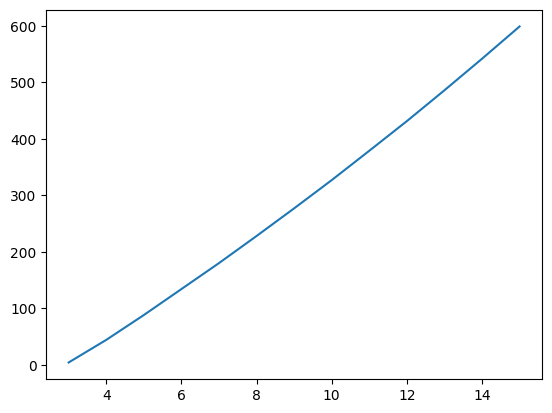

In [66]:
import matplotlib.pyplot as plt

plt.plot(qrange, obj_list)

## q=7

In [84]:
q = 6

G = lattice_adjacency((math.comb(q, 2),))

P, h, terms, obj = solve_with_site_permutation(q, G, sigma_fixed=range(q))
print("obj:", obj)
print_significant_terms(h, terms)

pauli_terms = collect_pauli_expansion(h, terms, q)
print(pauli_terms)
print(P)

obj: 3090.0
Significant terms (|h| >= 0.001):

=== hop2 (4 terms) ===
h = +0.125 · (S_1^+ S_2^- + S_2^+ S_1^-)
h = +0.25 · (S_2^+ S_3^- + S_3^+ S_2^-)
h = +0.5 · (S_3^+ S_4^- + S_4^+ S_3^-)
h = +0.5 · (S_4^+ S_5^- + S_5^+ S_4^-)

=== hop3 (16 terms) ===
h = -0.0625 · (S_1^+ S_2^- + S_2^+ S_1^-) Z_0
h = +0.1042 · (S_1^+ S_2^- + S_2^+ S_1^-) Z_3
h = +0.1042 · (S_1^+ S_2^- + S_2^+ S_1^-) Z_4
h = +0.1042 · (S_1^+ S_2^- + S_2^+ S_1^-) Z_5
h = +0.04167 · (S_2^+ S_3^- + S_3^+ S_2^-) Z_0
h = +0.04167 · (S_2^+ S_3^- + S_3^+ S_2^-) Z_1
h = +0.2083 · (S_2^+ S_3^- + S_3^+ S_2^-) Z_4
h = +0.2083 · (S_2^+ S_3^- + S_3^+ S_2^-) Z_5
h = +0.25 · (S_3^+ S_4^- + S_4^+ S_3^-) Z_0
h = +0.25 · (S_3^+ S_4^- + S_4^+ S_3^-) Z_1
h = +0.25 · (S_3^+ S_4^- + S_4^+ S_3^-) Z_2
h = +0.25 · (S_3^+ S_4^- + S_4^+ S_3^-) Z_5
h = +0.25 · (S_4^+ S_5^- + S_5^+ S_4^-) Z_0
h = +0.25 · (S_4^+ S_5^- + S_5^+ S_4^-) Z_1
h = +0.25 · (S_4^+ S_5^- + S_5^+ S_4^-) Z_2
h = +0.25 · (S_4^+ S_5^- + S_5^+ S_4^-) Z_3

=== hop4Z (8 terms) ===

## q=15

In [71]:
q = 15

G = lattice_adjacency((math.comb(q, 2),))

P, h, terms, obj = solve_with_site_permutation(q, G, sigma_fixed=range(q))
print_significant_terms(h, terms)
obj_list.append(obj)

pauli_terms = collect_pauli_expansion(h, terms, q)
print(pauli_terms)
print(P)

Significant terms (|h| >= 0.001):

=== hop2 (10 terms) ===
h = +0.4999 · (S_1^+ S_2^- + S_2^+ S_1^-)
h = +0.5 · (S_2^+ S_3^- + S_3^+ S_2^-)
h = +0.75 · (S_3^+ S_4^- + S_4^+ S_3^-)
h = +1 · (S_4^+ S_5^- + S_5^+ S_4^-)
h = +1.25 · (S_5^+ S_6^- + S_6^+ S_5^-)
h = -0.25 · (S_8^+ S_9^- + S_9^+ S_8^-)
h = +0.08109 · (S_10^+ S_11^- + S_11^+ S_10^-)
h = +0.25 · (S_11^+ S_12^- + S_12^+ S_11^-)
h = +1 · (S_12^+ S_13^- + S_13^+ S_12^-)
h = +1 · (S_13^+ S_14^- + S_14^+ S_13^-)

=== hop3 (6 terms) ===
h = -0.5 · (S_1^+ S_2^- + S_2^+ S_1^-) Z_0
h = +0.1126 · (S_10^+ S_11^- + S_11^+ S_10^-) Z_12
h = +0.1126 · (S_10^+ S_11^- + S_11^+ S_10^-) Z_13
h = +0.1126 · (S_10^+ S_11^- + S_11^+ S_10^-) Z_14
h = +0.25 · (S_11^+ S_12^- + S_12^+ S_11^-) Z_13
h = +0.25 · (S_11^+ S_12^- + S_12^+ S_11^-) Z_14

=== hop4Z (112 terms) ===
h = -0.5 · (S_2^+ S_3^- + S_3^+ S_2^-) Z_0 Z_1
h = -0.25 · (S_3^+ S_4^- + S_4^+ S_3^-) Z_0 Z_1
h = -0.25 · (S_3^+ S_4^- + S_4^+ S_3^-) Z_0 Z_2
h = -0.25 · (S_3^+ S_4^- + S_4^+ S_3^-) Z_

# Plot gate cost

## Fix qubits

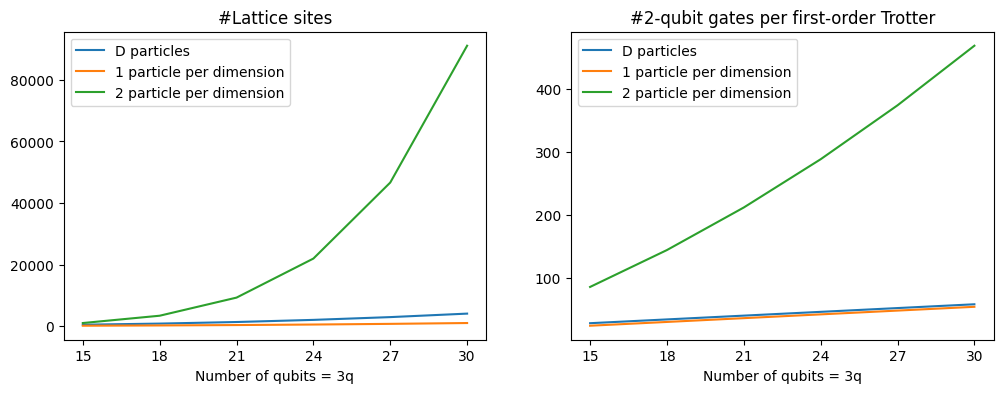

'\nplt.plot(q_list*D, [S_Dp(q*D)/G_Dp(q*D) * (q*D/np.log2(S_Dp(q*D))) for q in q_list], label="D particles")\nplt.plot(q_list*D, [(S_1pperD(q)**D)/(G_1pperD(q)*D) * (q*D/np.log2(S_1pperD(q)**D)) for q in q_list], label="1 particle per dimension")\nplt.plot(q_list*D, [(S_2pperD(q)**D)/(G_2pperD(q)*D) * (q*D/np.log2(S_2pperD(q)**D)) for q in q_list], label="2 particle per dimension")\nplt.legend()\nplt.title("First-quantized simulation score")\nplt.show()\n'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

D = 3

S_Dp = lambda q: math.comb(q, D)
S_1pperD = lambda q: q
S_2pperD = lambda q: math.comb(q, 2)

G_Dp = lambda q: 2*q-2
G_1pperD = lambda q: 2*q-2
G_2pperD = lambda q: (3*q**2/2 + 3*q - 24)

q_list = np.arange(5, 11)

fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(q_list*D, [S_Dp(q*D) for q in q_list], label="D particles")
ax[0].plot(q_list*D, [S_1pperD(q)**D for q in q_list], label="1 particle per dimension")
ax[0].plot(q_list*D, [S_2pperD(q)**D for q in q_list], label="2 particle per dimension")
ax[0].set_xticks(q_list*D)
ax[0].set_xlabel("Number of qubits = 3q")
ax[0].set_title("#Lattice sites")
ax[0].legend()

ax[1].plot(q_list*D, [G_Dp(q*D) for q in q_list], label="D particles")
ax[1].plot(q_list*D, [G_1pperD(q)*D for q in q_list], label="1 particle per dimension")
ax[1].plot(q_list*D, [G_2pperD(q)*D for q in q_list], label="2 particle per dimension")
ax[1].set_xticks(q_list*D)
ax[1].set_title("#2-qubit gates per first-order Trotter")
ax[1].set_xlabel("Number of qubits = 3q")
ax[1].legend()

'''
ax[2].plot(q_list*D, [S_Dp(q*D)/G_Dp(q*D) for q in q_list], label="D particles")
ax[2].plot(q_list*D, [(S_1pperD(q)**D)/(G_1pperD(q)*D) for q in q_list], label="1 particle per dimension")
ax[2].plot(q_list*D, [(S_2pperD(q)**D)/(G_2pperD(q)*D) for q in q_list], label="2 particle per dimension")
ax[2].set_xticks(q_list*D)
ax[2].set_title("#Lattice sites per gate")
ax[2].set_xlabel("Number of qubits = 3q")
ax[2].legend()

ax[3].plot(q_list*D, [math.log2(S_Dp(q*D))/(q*D) for q in q_list], label="D particles")
ax[3].plot(q_list*D, [math.log2(S_1pperD(q)**D)/(q*D) for q in q_list], label="1 particle per dimension")
ax[3].plot(q_list*D, [math.log2(S_2pperD(q)**D)/(q*D) for q in q_list], label="2 particle per dimension")
ax[3].set_xticks(q_list*D)
ax[3].set_ylim((0,1))
ax[3].set_title("log2(#Lattice sites)/#qubits")
ax[3].set_xlabel("Number of qubits = 3q")
ax[3].legend()
'''

#fig.suptitle("3D lattice")
plt.show()

'''
plt.plot(q_list*D, [S_Dp(q*D)/G_Dp(q*D) * (q*D/np.log2(S_Dp(q*D))) for q in q_list], label="D particles")
plt.plot(q_list*D, [(S_1pperD(q)**D)/(G_1pperD(q)*D) * (q*D/np.log2(S_1pperD(q)**D)) for q in q_list], label="1 particle per dimension")
plt.plot(q_list*D, [(S_2pperD(q)**D)/(G_2pperD(q)*D) * (q*D/np.log2(S_2pperD(q)**D)) for q in q_list], label="2 particle per dimension")
plt.legend()
plt.title("First-quantized simulation score")
plt.show()
'''

## Fix lattice sites

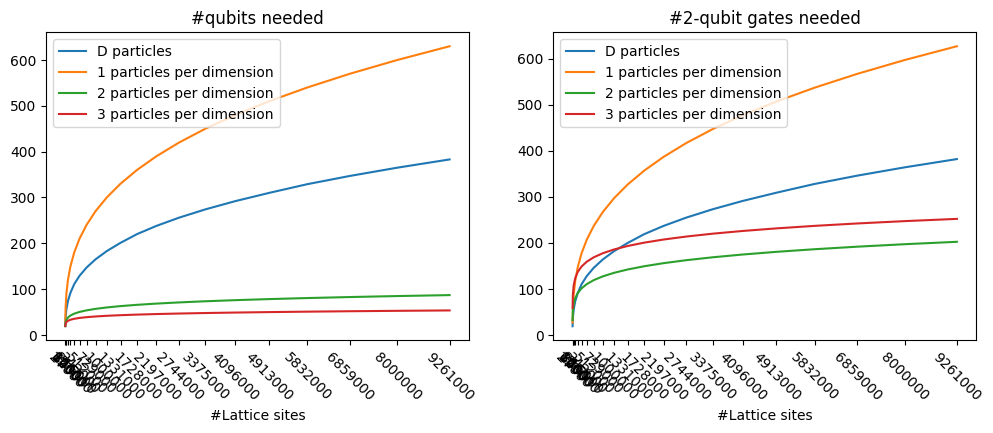

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

# -------------------------
# S-type inverses
# -------------------------

def inv_S_Dp(S, D):
    """
    Inverse of S_Dp(q) = comb(q, D).
    Returns the smallest integer q >= D such that comb(q, D) >= S.
    """
    if D < 0:
        raise ValueError("D must be non-negative")

    # For S <= 1, comb(D, D) = 1 already satisfies it (for D >= 0).
    if S <= 1:
        return D

    q = D
    while math.comb(q, D) < S:
        q += 1
    return q


def inv_S_1pperD(S):
    """
    Inverse of S_1pperD(q) = q.
    Here S is the 'space' value; q = S.
    """
    return S


def inv_S_2pperD(S):
    """
    Inverse of S_2pperD(q) = comb(q, 2) = q (q - 1) / 2.
    Returns the smallest integer q >= 2 such that comb(q, 2) >= S.
    """
    if S <= 0:
        return 2  # comb(2,2) = 1 >= S for S <= 1

    # Start from the quadratic solution and adjust with comb for safety.
    q = int((1 + math.sqrt(1 + 8 * S)) // 2)

    # Ensure comb(q, 2) >= S
    while math.comb(q, 2) < S:
        q += 1
    # And that q is minimal
    while q > 2 and math.comb(q - 1, 2) >= S:
        q -= 1

    return q

def inv_S_2pperD_half(S):
    return np.sqrt(4*S) #(-1 + np.sqrt(24*S + 25))/3

def inv_S_npperD(S, n):
    return n*S**(1/n) #(-1 + np.sqrt(24*S + 25))/3

    
'''
# -------------------------
# G-type inverses
# -------------------------

def inv_G_Dp(G):
    """
    Inverse of G_Dp(q) = 2*q - 2.
    Assume G is a valid value of this expression.
    """
    return (G + 2) // 2  # integer q


def inv_G_1pperD(G):
    """
    Inverse of G_1pperD(q) = 2*q - 2.
    Same form as G_Dp.
    """
    return (G + 2) // 2  # integer q


def inv_G_2pperD(G):
    """
    Inverse of G_2pperD(q) = (3/2)*q^2 + 3*q - 24.

    Solve:
      (3/2) q^2 + 3 q - 24 = G
    => q = -1 + sqrt(6G + 153) / 3  (take positive root)

    Returns integer q (rounded to nearest, then checked).
    """
    # Closed-form float estimate
    q_float = -1 + math.sqrt(6 * G + 153) / 3

    # Round to nearest int and adjust if necessary
    q = int(round(q_float))

    # Make sure we got the exact inverse if G is consistent
    # (optional safety step; you can drop this if you trust inputs)
    while (3 * q * q) / 2 + 3 * q - 24 < G:
        q += 1
    while q > 0 and (3 * (q - 1) * (q - 1)) / 2 + 3 * (q - 1) - 24 >= G:
        q -= 1

    return q
'''


G_Dp = lambda q: 2*q-2
G_1pperD = lambda q: 2*q-2
G_2pperD = lambda q: (3*q**2/2 + 3*q - 24)
G_2pperD_half = lambda q: 2*(q-2) + 6*(q/2-1) #3/4 * q**2 + 1/2 * q - 4
G_npperD = lambda q, n: gate_count(n_par_linear_scaling(int(np.ceil(q/n)), n)) #3/4 * q**2 + 1/2 * q - 4
G_npperD_formula = lambda q, n: ((n-1)*2**(n+1) + 2)*(q/n - 1)

D = 3
S_list = np.array(range(10, 211, 10))**D #np.array([4,8,9,16,25,27,36,49,64,81,100,121,125])**D
fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(S_list, [inv_S_Dp(S, D) for S in S_list], label="D particles")
#ax[0].plot(S_list, [inv_S_1pperD(S**(1/D))*D for S in S_list], label="1 particle per dimension")
#ax[0].plot(S_list, [inv_S_2pperD(S**(1/D))*D for S in S_list], label="2 particles per dimension")
#ax[0].plot(S_list, [inv_S_2pperD_half(S**(1/D))*D for S in S_list], label="2 particles per dimension (half)")

ax[1].plot(S_list, [G_Dp(inv_S_Dp(S, D))/2 for S in S_list], label="D particles")
#ax[1].plot(S_list, [G_1pperD(inv_S_1pperD(S**(1/D)))*D for S in S_list], label="1 particle per dimension")
#ax[1].plot(S_list, [G_2pperD(inv_S_2pperD(S**(1/D)))*D for S in S_list], label="2 particles per dimension")
#ax[1].plot(S_list, [G_2pperD_half(inv_S_2pperD_half(S**(1/D)))*D for S in S_list], label="2 particles per dimension (half)")

for n in [1, 2, 3]:
    ax[0].plot(S_list, [inv_S_npperD(S**(1/D), n)*D for S in S_list], label=f"{n} particles per dimension")
    #ax[1].plot(S_list, [G_npperD(inv_S_npperD(S**(1/D), n), n)*D for S in S_list], label=f"{n} particles per dimension")
    ax[1].plot(S_list, [G_npperD_formula(inv_S_npperD(S**(1/D), n), n)*D/2 for S in S_list], label=f"{n} particles per dimension")

ax[0].set_xticks(S_list, S_list, rotation=-45)
ax[0].set_xlabel("#Lattice sites")
ax[0].set_title("#qubits needed")
ax[0].legend()

ax[1].set_xticks(S_list, S_list, rotation=-45)
ax[1].set_xlabel("#Lattice sites")
ax[1].set_title("#2-qubit gates needed")
ax[1].legend()

plt.show()

In [33]:
[G_npperD(inv_S_npperD(S**(1/D), 2), 2)*D for S in S_list]

[90,
 90,
 120,
 120,
 150,
 150,
 180,
 180,
 210,
 210,
 210,
 240,
 240,
 240,
 240,
 270,
 270,
 270,
 270]